# Assignment 1 - Coding
### Andres Arias Medina
### Z23987588


## Question 11: Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# no_x: number of data
# you can change the value of no_x
no_x = 20

# generate 1D variable x and target y
x = np.linspace(0, 1, no_x)

# eps = level of random noise
# You can change eps value, if you want
eps = 0.2

np.random.seed(42)
y = 1 + x + eps * np.random.random(size=len(x))

### 11.1 change above x into a matrix X in p.15
####      (add one column of ‘1’s)


In [2]:
# Using the function column_stack we can fill column 0 o f the matriz with ones using numpy fucntion .ones
X = np.column_stack((np.ones(len(x)), x)) #stack [1 | x] as columns -> shape (no_x, 2)
print(x[:4]) # original x
print('-------')
print(X[:4]) # each row is now [1, x_i], ready for the product X @ w

[0.         0.05263158 0.10526316 0.15789474]
-------
[[1.         0.        ]
 [1.         0.05263158]
 [1.         0.10526316]
 [1.         0.15789474]]


### 11.1 change y to a column vector

In [3]:
# Reshape y from a flat array (no_x,) into a column vector (no_x, 1)
y = y.reshape(-1, 1) # -1 lets numpy infer the row count, so it adapts if no_x changes
print(y[:3])

[[1.07490802]
 [1.24277444]
 [1.25166195]]


#### 11.2 Compute the coefficient of linear regression line

In [4]:
#Calculating coefficients for y = b0 + b1x using the course formula beta = (X^T X)^-1 X^T y
# beta is the "coeff" vector referred to in the template
beta = np.linalg.inv(X.T @ X) @ X.T @ y
print('b0:', beta[0]) # intercept
print('b1:', beta[1]) # slope

b0: [1.11364649]
b1: [0.95578793]


In [5]:
# # Apply the fitted model to every training point
# y^​=b0​+b1​x
y_pred = X @ beta
print(y_pred[:4])

[[1.11364649]
 [1.16395112]
 [1.21425575]
 [1.26456038]]


#### 11.2 draw data points and regression line

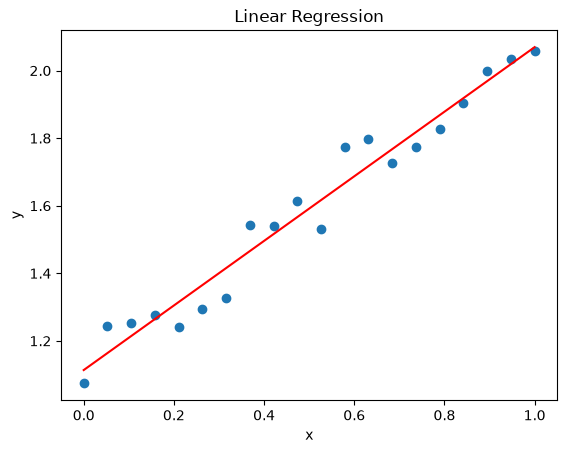

In [6]:
# Draw data and regression
plt.scatter(x, y)
plt.plot(x, y_pred, 'r')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")

plt.show()

#### 11.3 Given a value of x=0.8, predict y value

In [7]:
x_new = 0.8
y_new = beta[0] + beta[1] * x_new
print("Predicted y =", y_new)

Predicted y = [1.87827684]


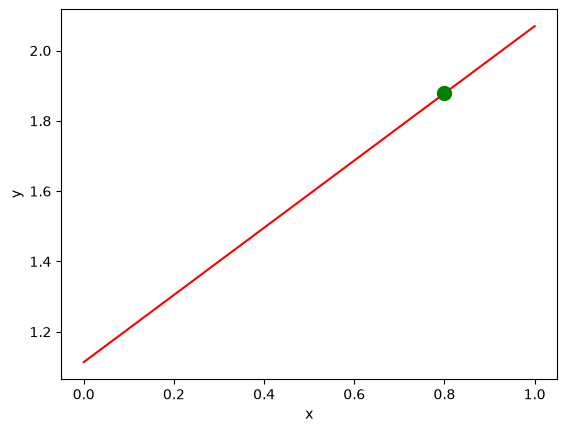

In [8]:
# 0.8 x point with its output y
plt.plot(x, y_pred, 'r')
plt.plot(x_new, y_new, 'go', markersize=10)

plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Using Sklearn

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() # fit_intercept=True by default

# pass the RAW feature (no_x, 1), reusing X would add a redundant column of 1s
model.fit(x.reshape(-1, 1), y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.96]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.11]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.36]


In [10]:
print("b0 =", model.intercept_)
print("b1 =", model.coef_)

b0 = [1.11364649]
b1 = [[0.95578793]]


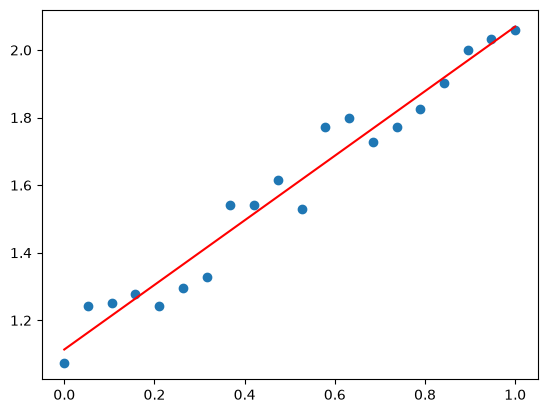

In [11]:
y_line = model.predict(x.reshape(-1, 1)) # sklearn's equivalent of X @ beta
plt.scatter(x, y)
plt.plot(x, y_line, 'r')

In [12]:
x_new1 = np.array([[0.8]])
y_new1 = model.predict(x_new1)
print("Predicted y =", y_new1[0])

Predicted y = [1.87827684]


### Compare results

In [13]:
# Identical up to floating point precision
print("Predicted y traditional method =", y_new)
print("Predicted y with Sklearn=", y_new1)

Predicted y traditional method = [1.87827684]
Predicted y with Sklearn= [[1.87827684]]


## Question 12: Logistic Regression

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Hyperparameters
alpha = 0.01
# You can change num_iter value
num_iter = 1000

# Create dataset
X, y = make_classification(
        n_samples=100, n_features=2, n_redundant=0,
        n_informative=2, random_state=1, n_clusters_per_class=1 )



#### 12.1 Given a matrix X, add one column of ‘1’s as the first column

In [15]:
def add_ones(X):
    X = np.column_stack((np.ones(len(X)), X))
    return X

x = np.linspace(0, 1, 5)
x = add_ones(x)
print(x)

[[1.   0.  ]
 [1.   0.25]
 [1.   0.5 ]
 [1.   0.75]
 [1.   1.  ]]


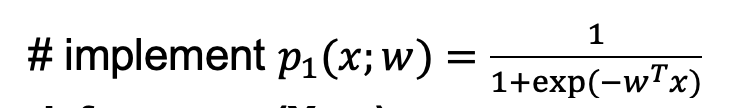

In [16]:
def comp_p(X, w):
    z = X @ w # First we compute z = Xw
    p = 1 / (1 + np.exp(-z)) # Then we apply the sigmoid function
    return p

# X = data
# w = current weights
# p = probability of each sample to belong to class 1

In [17]:
# Train w
X_1 = add_ones(X)
w = np.zeros(X_1.shape[1])
m = y.size
# Looking our matrix
print(X_1[:3])

[[ 1.         -1.04948638  0.8786438 ]
 [ 1.          0.8780991   0.89551051]
 [ 1.          0.95928819  1.03967316]]


#### Gradient
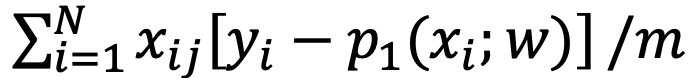

In [18]:
for i in range(num_iter):
    # Compute probability
    p = comp_p(X_1, w)

    # Compute gradient
    gradient = (X_1.T @ (y - p)) / m

    # Update w
    w = w + alpha * gradient

#### Compute prediction probabilities using the coefficients w 

In [19]:
p = comp_p(X_1, w)
p

array([0.89918895, 0.12655468, 0.10787015, 0.92092525, 0.86704611,
       0.77919235, 0.13864996, 0.92571115, 0.15766253, 0.72318483,
       0.07210131, 0.13916477, 0.12343545, 0.12355852, 0.11048985,
       0.11500715, 0.88023161, 0.9069772 , 0.79812855, 0.82980401,
       0.91006037, 0.05058105, 0.94868269, 0.09670863, 0.06142035,
       0.92587569, 0.10327526, 0.09563898, 0.08029062, 0.85330367,
       0.89669564, 0.93538298, 0.88555794, 0.11845899, 0.07679175,
       0.89402752, 0.130771  , 0.08895837, 0.06173   , 0.13544306,
       0.95685783, 0.93021065, 0.08852629, 0.11915347, 0.75689769,
       0.08953093, 0.8596794 , 0.92855956, 0.10172809, 0.95154755,
       0.86240676, 0.06453199, 0.86985663, 0.86083343, 0.9713103 ,
       0.05038468, 0.12665105, 0.09168392, 0.87373328, 0.9560449 ,
       0.09292466, 0.08225333, 0.93840013, 0.07019721, 0.15059206,
       0.98014797, 0.14251442, 0.11482475, 0.06523642, 0.76127573,
       0.07439473, 0.14160163, 0.10589459, 0.91601533, 0.85440

In [20]:
prediction = (p >= 0.5).astype(int)
prediction

array([1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1])

In [21]:
accuracy = np.mean(prediction == y)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [22]:
# Save results from 12.1 (without L2) aiming for the next point
w_without_L2 = w.copy()
accuracy_without_L2 = accuracy

### 12.2
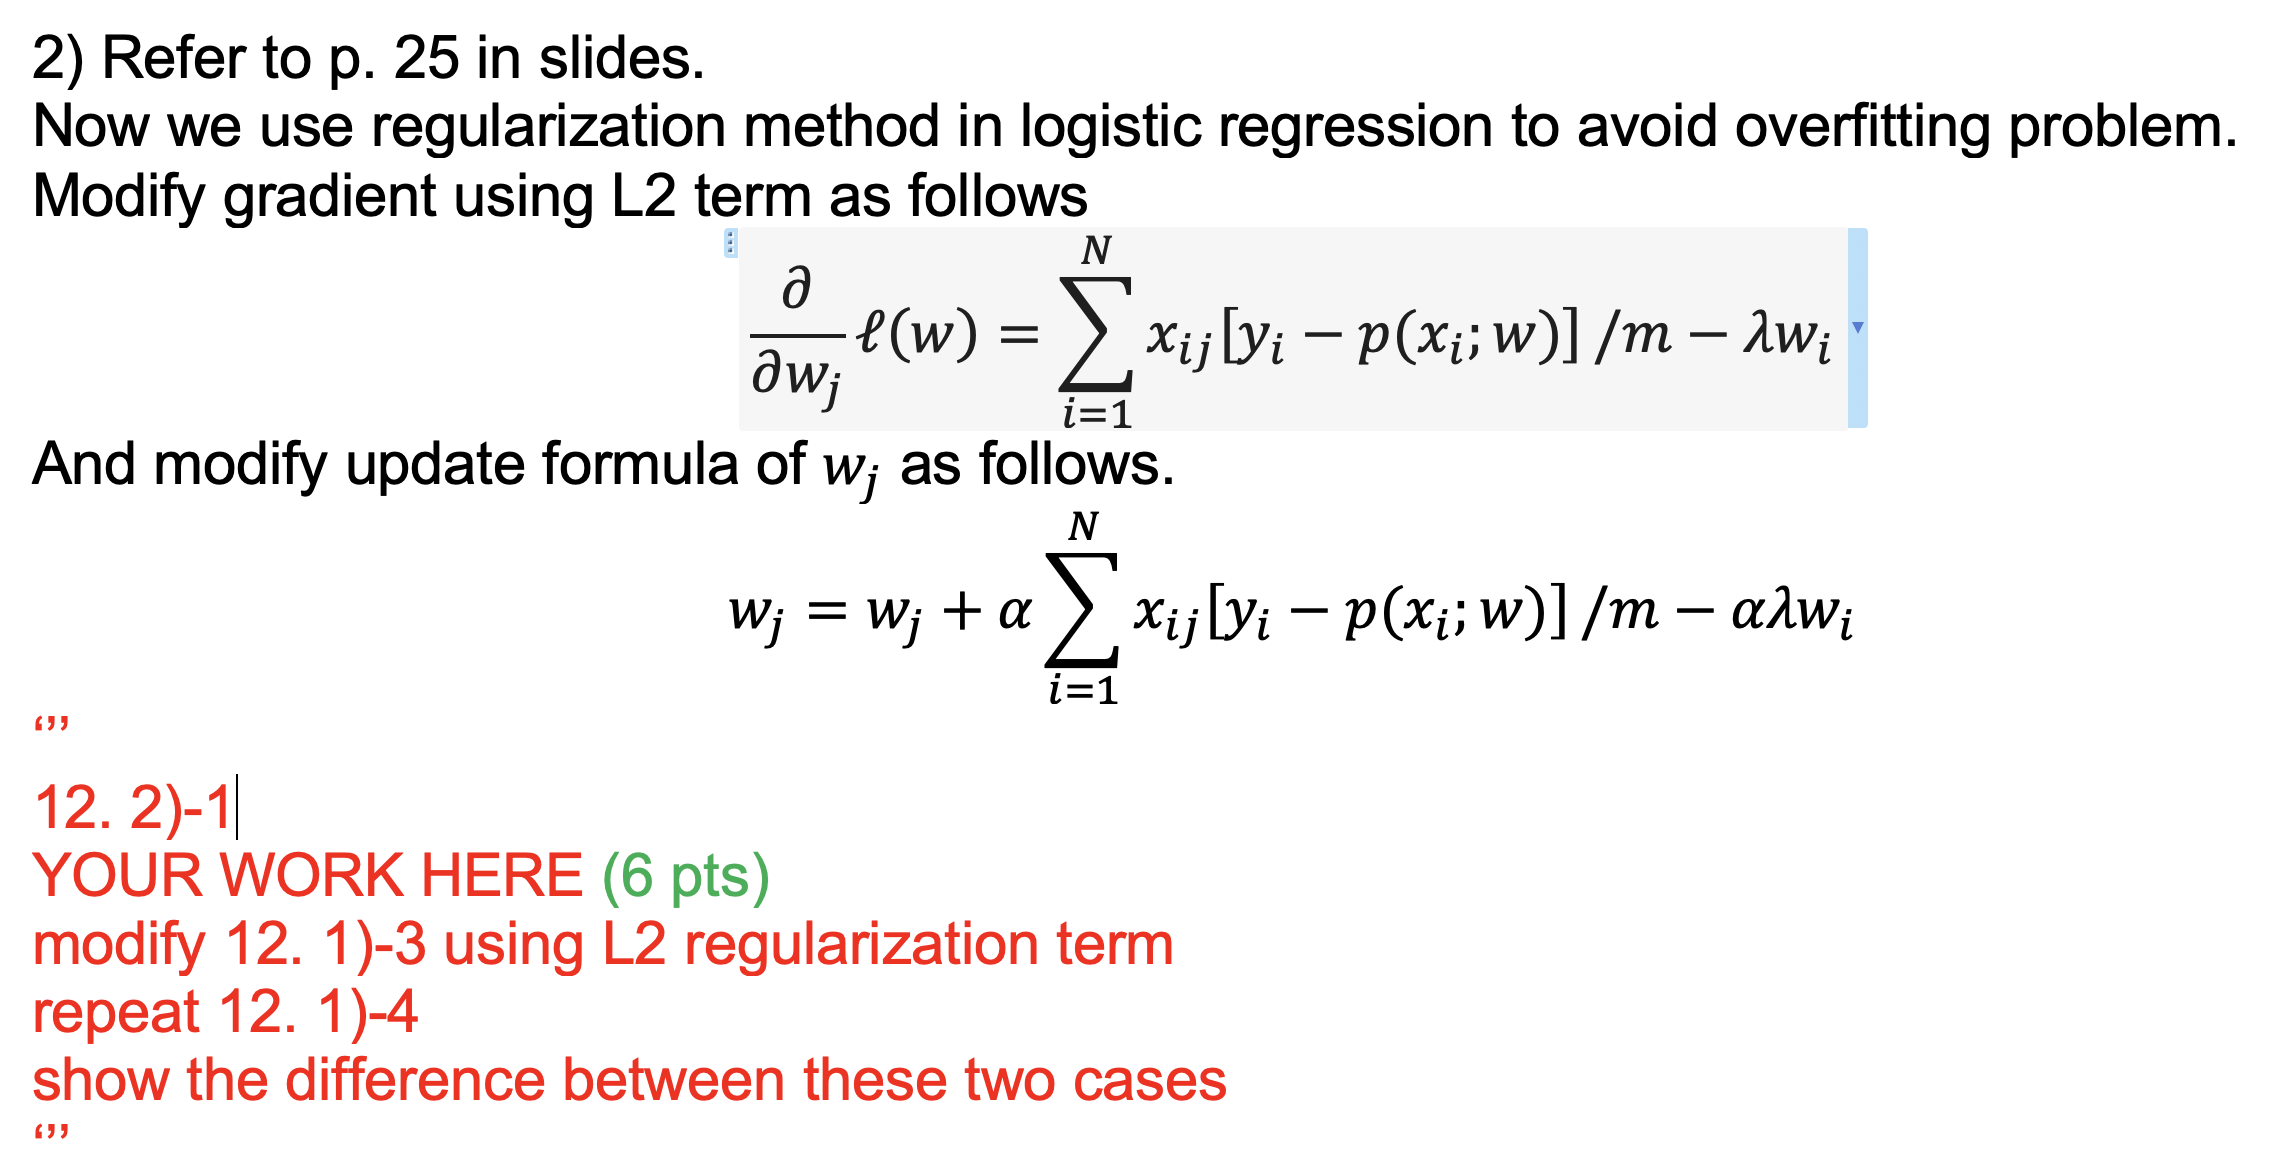

#### Modify the gradient using L2 regularization
L2 regularization is used to penalize large weights and reduce overfitting.

We modify the gradient from 12.1-3 by adding the L2 regularization term:

$$
gradient = \frac{X_1^T(y-p)}{m} - \lambda w
$$

The weights are updated using:

$$
w = w + \alpha \cdot gradient
$$

In [23]:
# Using lambda to control the strength of the regularization
lambda_reg = 0.01

# Initialize the weights again to zero before training the regularized model
w = np.zeros(X_1.shape[1])

# Train the logistic regression model with L2 regularization
for i in range(num_iter):

    # Compute prediction probability
    p = comp_p(X_1, w)

    # Compute gradient with L2 regularization
    gradient = (X_1.T @ (y - p)) / m - lambda_reg * w

    # Update weights
    w = w + alpha * gradient

In [24]:
# After training, we compute the prediction probabilities, 
# convert them into class valuesand calculate the accuracy

p = comp_p(X_1, w)

# Compute class values
prediction = (p >= 0.5).astype(int)

# Compute accuracy
accuracy_with_L2 = np.mean(prediction == y)

print("Accuracy with L2:", accuracy_with_L2)

Accuracy with L2: 1.0


### Comparison: Without L2 vs. With L2

In [25]:
print("Without L2:")
print("Weights:", w_without_L2)
print("Accuracy:", accuracy_without_L2)

print("\nWith L2:")
print("Weights:", w)
print("Accuracy:", accuracy_with_L2)

Without L2:
Weights: [-0.00925468 -2.13694733 -0.05143972]
Accuracy: 1.0

With L2:
Weights: [-0.00964725 -2.04855838 -0.05008817]
Accuracy: 1.0


In [26]:
# Compare several values of lambda to see the effect of L2 regularization
for lambda_reg in [0, 0.1, 1, 10]:

    # Reset the weights to zero before each training run
    w = np.zeros(X_1.shape[1])

    # Same 1000 iterations as in 12.2, now with the current lambda
    for i in range(num_iter):
        p = comp_p(X_1, w)
        gradient = (X_1.T @ (y - p)) / m - lambda_reg * w
        w = w + alpha * gradient

    # Evaluate this model
    p = comp_p(X_1, w)
    prediction = (p >= 0.5).astype(int)
    accuracy = np.mean(prediction == y)

    # norm of w = overall size of the weights; p.max() = highest confidence
    print("lambda =", lambda_reg,
          "| ||w|| =", round(np.linalg.norm(w), 4),
          "| accuracy =", round(accuracy, 2),
          "| highest p =", round(p.max(), 4))


lambda = 0 | ||w|| = 2.1376 | accuracy = 1.0 | highest p = 0.9821
lambda = 0.1 | ||w|| = 1.4839 | accuracy = 1.0 | highest p = 0.9412
lambda = 1 | ||w|| = 0.4076 | accuracy = 1.0 | highest p = 0.6814
lambda = 10 | ||w|| = 0.051 | accuracy = 1.0 | highest p = 0.5238


### Comparison without L2 vs with L2 with my extra implementation

The accuracy stays the same while ‖w‖ shrinks by orders of magnitude. With separable
classes the log-likelihood has no maximum, the model keeps growing ‖w‖ to push the
probabilities toward 0 and 1 and L2 is what stops that growth. 

Accuracy does not react because only the **sign** of $w^\top x$ decides the class, not its magnitude. What changes is confidence, the highest predicted probability drops as λ grows. Large weights mean overconfident predictions resting on a few boundary points, which is the overfitting L2 prevents, too large a λ underfits instead.

## Using sklearn

In [27]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression()
model.fit(X, y)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

LogisticRegression() applies L2 by default (`C=1.0`), so comparing it against our
unregularised version is not like for like.

In [28]:
# Making predictions using the trained model
prediction_sklearn = model.predict(X)

In [29]:
# Calculate accuracy for sklearn model
accuracy_sklearn = np.mean(prediction_sklearn == y)

print("Accuracy:", accuracy_sklearn)

Accuracy: 1.0


#### Comparing both models

In [30]:
print("Firtst implementation:", accuracy_without_L2)
print("Scikit-learn:", accuracy_sklearn)

Firtst implementation: 1.0
Scikit-learn: 1.0
